# Loan Default / Credit Risk Prediction — Single Real Dataset Edition

**Business problem:** Predict whether a loan applicant is likely to default so a lender can assess credit risk more consistently.

**What changed:** This version uses **only one real, publicly available loan dataset** from Kaggle (`Loan_Default_csv.xlsx`) — no second credit-risk file is required or used.

```
Filtering  ->  Dataset Create  ->  Realistic check  ->  Clean & Preprocess
   ->  Feature Engineering  ->  Feature Selection  ->  Train/Test Split (70/30)
   ->  Train 3 Models  ->  Evaluate  ->  Feature Importance  ->  Predict new applicant
```

**Data source used:**
- `Loan_Default_csv.xlsx` — ~148,670 mortgage/loan applicants, 34 columns (age bands, income, loan amount, interest rate, credit score, DTI, default status, etc.)

**Approach:** Build and compare three binary-classification models:
1. **Logistic Regression** — interpretable statistical baseline
2. **Decision Tree** — rule-based model, easy to visualize
3. **Random Forest** — ensemble of decision trees for more complex patterns

Every calculation step below prints intermediate numbers (row counts, medians used for imputation, correlation values, etc.) so the full logic is visible, not hidden inside a black box.


## 1. Install & import libraries

Run this cell first in Google Colab. The installation command is harmless if the packages are already installed.


In [1]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn ipywidgets openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

pd.set_option('display.width', 140)
np.random.seed(42)
sns.set_style("whitegrid")


## 2. Load the real dataset

Upload `Loan_Default_csv.xlsx` to your Colab session (or Google Drive), then load it.


In [2]:
df_raw = pd.read_excel("Loan_Default_csv.xlsx")

print("Dataset shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))
print("\nMissing values (top 15 by count):")
print(df_raw.isna().sum().sort_values(ascending=False).head(15))
print("\nSample of first 5 rows:")
display(df_raw.head())


Dataset shape: (150156, 34)

Columns: ['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']

Missing values (top 15 by count):
Upfront_charges              41704
rate_of_interest             38354
Interest_rate_spread         36975
dtir1                        26146
property_value               17252
LTV                          17205
income                       11327
loan_limit                    3375
approv_in_adv                 3154
age                           2446
loan_purpose                  2387
term   

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,138323,2019,cf,Joint,nopre,type1,p4,l1,nopc,nob/c,...,EXP,590.0,EXP,65-74,to_inst,93.269231,north,direct,0,40.0
1,25007,2019,cf,Joint,nopre,Type1,p4,l1,nopc,nob/c,...,EXP,640.0,EXP,45-54,to_inst,70.432692,North,direct,0,42.0
2,71074,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EQUI,809.0,EXP,35-44,not_inst,NaN,south,direct,1,NaN
3,134503,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CRIF,519.0,CIB,35-44,not_inst,86.694511,south,direct,0,45.0
4,114466,2019,cf,Sex Not Available,pre,type2,p3,l1,nopc,b/c,...,CRIF,706.0,EXP,55-64,to_inst,87.133891,south,direct,0,24.0


## 3. Filtering

Two things happen here:
- **Column filtering** — keep only the columns that are usable and relevant to credit risk (age, income, loan amount, interest rate, credit score, debt-to-income, and the default target). Many original columns are mostly empty or not relevant (e.g. `Upfront_charges`, `Security_Type`, `construction_type`).
- **Row filtering** — remove rows that are physically impossible or unusable (e.g. non-positive income).


In [3]:
# --- Column filtering ---
# Keep only columns that map onto credit-risk concepts and aren't mostly empty
keep_cols = ['age', 'income', 'loan_amount', 'rate_of_interest', 'Credit_Score', 'dtir1', 'Status']
df = df_raw[keep_cols].copy()

print(f"Kept {len(keep_cols)} of {df_raw.shape[1]} original columns")
print("Columns kept:", keep_cols)

# --- Row filtering ---
before = len(df)
df = df[df['income'] > 0]
df = df.reset_index(drop=True)
print(f"\nRemoved {before - len(df)} invalid rows (income <= 0): {before} -> {len(df)}")
print("\nMissing values after column/row filtering:")
print(df.isna().sum())


Kept 7 of 34 original columns
Columns kept: ['age', 'income', 'loan_amount', 'rate_of_interest', 'Credit_Score', 'dtir1', 'Status']

Removed 12884 invalid rows (income <= 0): 150156 -> 137272

Missing values after column/row filtering:
age                  2070
income                  0
loan_amount             0
rate_of_interest    35379
Credit_Score         2078
dtir1               15860
Status                  0
dtype: int64


## 4. Dataset Create — map to a clean schema

The raw columns are renamed and lightly transformed into a consistent modeling schema:

| Shared feature | Source column | Notes |
|---|---|---|
| `age` | `age` (text ranges like `"25-34"`) | Age bands are converted to their numeric midpoint |
| `annual_income` | `income` (monthly) | Annualized: `income x 12` |
| `loan_amount` | `loan_amount` | Same concept |
| `interest_rate` | `rate_of_interest` | Same concept |
| `credit_score_raw` | `Credit_Score` (approx 500–900) | Already numeric |
| `debt_to_income_pct` | `dtir1` | Debt-to-income ratio |
| `target` | `Status` | Already coded `1 = default, 0 = no default` |


In [4]:
def age_range_to_midpoint(a):
    """Convert text age bands into a single numeric midpoint."""
    mapping = {'<25': 22, '25-34': 29.5, '35-44': 39.5, '45-54': 49.5,
               '55-64': 59.5, '65-74': 69.5, '>74': 80}
    return mapping.get(a, np.nan)

# Build clean dataframe
combined = pd.DataFrame()
combined['age'] = df['age'].apply(age_range_to_midpoint)
combined['annual_income'] = df['income'] * 12          # monthly -> annual
combined['loan_amount'] = df['loan_amount'].astype(float)
combined['interest_rate'] = df['rate_of_interest']
combined['credit_score_raw'] = df['Credit_Score'].astype(float)
combined['debt_to_income_pct'] = df['dtir1']
combined['target'] = df['Status']

print("Cleaned dataset shape:", combined.shape)
print("\nMissing values before cleaning:")
print(combined.isna().sum())
print("\nTarget distribution:")
print(combined['target'].value_counts(normalize=True).round(3))


Cleaned dataset shape: (137272, 7)

Missing values before cleaning:
age                    2205
annual_income             0
loan_amount               0
interest_rate         35379
credit_score_raw       2078
debt_to_income_pct    15860
target                    0
dtype: int64

Target distribution:
target
0    0.753
1    0.247
Name: proportion, dtype: float64


## 5. Realistic check

A quick sanity check that the dataset behaves like real financial data: reasonable ranges and a sensible default rate.


In [5]:
print("Overall default rate:", round(combined['target'].mean() * 100, 2), "%")
print("\nAge range:", combined['age'].min(), "-", combined['age'].max())
print("Annual income range:", combined['annual_income'].min(), "-", combined['annual_income'].max())
print("Loan amount range:", combined['loan_amount'].min(), "-", combined['loan_amount'].max())
print("Credit score range:", combined['credit_score_raw'].min(), "-", combined['credit_score_raw'].max())
print("Interest rate range:", combined['interest_rate'].min(), "-", combined['interest_rate'].max())


Overall default rate: 24.72 %

Age range: 22.0 - 80.0
Annual income range: 720.0 - 119999988.0
Loan amount range: -50000.0 - 99999999.0
Credit score range: 0.0 - 1200.0
Interest rate range: -5.0 - 99.0


## 6. Clean & Preprocess

Steps, each printed explicitly:
1. Remove any remaining rows with impossible values.
2. **Impute** missing numeric values with the column median (median is used instead of mean because these financial variables are skewed by outliers).
3. **Clip outliers** at the 1st/99th percentile so a few extreme values don't distort the models.


In [6]:
# 1. Remove remaining invalid rows
before = len(combined)
combined = combined[combined['annual_income'] > 0]
combined = combined[(combined['age'] >= 18) & (combined['age'] <= 90)]
combined = combined[combined['loan_amount'] > 0]
combined = combined.reset_index(drop=True)
print(f"Rows after final validity check: {before} -> {len(combined)} ({len(combined)/before*100:.1f}% retained)")

# 2. Median imputation
medians = {}
for col in ['interest_rate', 'debt_to_income_pct', 'credit_score_raw', 'age']:
    med = combined[col].median()
    medians[col] = med
    combined[col] = combined[col].fillna(med)

print("\nMedians used for imputation:")
for k, v in medians.items():
    print(f"  {k}: {v:.2f}")

# 3. Outlier clipping (1st-99th percentile)
print("\nOutlier clipping:")
for col in ['annual_income', 'loan_amount', 'interest_rate', 'debt_to_income_pct']:
    q1, q99 = combined[col].quantile([0.01, 0.99])
    n_clipped = ((combined[col] < q1) | (combined[col] > q99)).sum()
    combined[col] = combined[col].clip(q1, q99)
    print(f"  {col}: clipped {n_clipped} outlier rows to range [{q1:.1f}, {q99:.1f}]")

print("\nMissing values after cleaning (should all be 0):")
print(combined.isna().sum())
print("\nFinal cleaned shape:", combined.shape)
combined.describe().round(2)


Rows after final validity check: 137272 -> 134795 (98.2% retained)

Medians used for imputation:
  interest_rate: 3.99
  debt_to_income_pct: 39.00
  credit_score_raw: 700.00
  age: 49.50

Outlier clipping:
  annual_income: clipped 2503 outlier rows to range [15120.0, 334800.0]
  loan_amount: clipped 2447 outlier rows to range [66500.0, 886500.0]
  interest_rate: clipped 2001 outlier rows to range [3.0, 5.5]
  debt_to_income_pct: clipped 2131 outlier rows to range [8.0, 60.0]

Missing values after cleaning (should all be 0):
age                   0
annual_income         0
loan_amount           0
interest_rate         0
credit_score_raw      0
debt_to_income_pct    0
target                0
dtype: int64

Final cleaned shape: (134795, 7)


,age,annual_income,loan_amount,interest_rate,credit_score_raw,debt_to_income_pct,target
count,134795.00,134795.00,134795.00,134795.00,134795.00,134795.00,134795.00
mean,50.96,82553.26,326983.62,4.06,700.06,37.95,0.25
std,14.15,54930.10,172601.59,0.46,118.17,9.88,0.43
min,22.00,15120.00,66500.00,2.99,0.00,8.00,0.00
25%,39.50,45360.00,196500.00,3.88,601.00,33.00,0.00
50%,49.50,69120.00,296500.00,3.99,700.00,39.00,0.00
75%,59.50,102960.00,436500.00,4.25,799.00,44.00,0.00
max,80.00,334800.00,886500.00,5.50,1200.00,60.00,1.00


## 7. Quick exploratory analysis


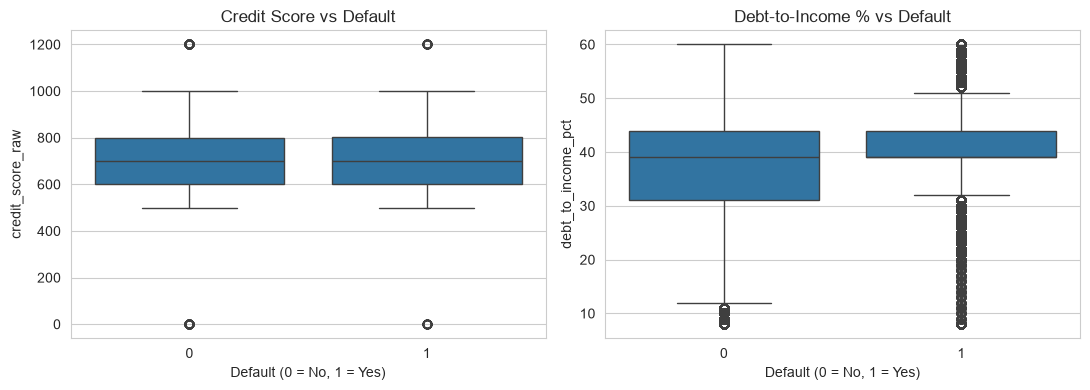

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(x="target", y="credit_score_raw", data=combined, ax=axes[0])
axes[0].set_title("Credit Score vs Default")
axes[0].set_xlabel("Default (0 = No, 1 = Yes)")

sns.boxplot(x="target", y="debt_to_income_pct", data=combined, ax=axes[1])
axes[1].set_title("Debt-to-Income % vs Default")
axes[1].set_xlabel("Default (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()


## 8. Feature Engineering

Creating new features that are often more predictive than raw columns on their own:
- **`loan_to_income_ratio`** = loan amount / annual income — a classic affordability signal
- **`credit_score_normalized`** = credit score rescaled to a common 0–100 range
- **`high_dti_flag`** = 1 if debt-to-income is above 40% (a common lending risk threshold), else 0
- **`age_group`** = age bucketed into ranges, useful for later analysis/visualization


In [8]:
combined['loan_to_income_ratio'] = combined['loan_amount'] / combined['annual_income']

cs_min, cs_max = combined['credit_score_raw'].min(), combined['credit_score_raw'].max()
combined['credit_score_normalized'] = (combined['credit_score_raw'] - cs_min) / (cs_max - cs_min) * 100
print(f"credit_score_raw range [{cs_min:.0f}, {cs_max:.0f}] rescaled to credit_score_normalized [0, 100]")

combined['high_dti_flag'] = (combined['debt_to_income_pct'] > 40).astype(int)

combined['age_group'] = pd.cut(
    combined['age'],
    bins=[17, 25, 35, 45, 55, 65, 91],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

print("\nEngineered feature summary:")
print(combined[['loan_to_income_ratio', 'credit_score_normalized', 'high_dti_flag']].describe().round(3))
print("\nApplicants per age group:")
print(combined['age_group'].value_counts().sort_index())


credit_score_raw range [0, 1200] rescaled to credit_score_normalized [0, 100]

Engineered feature summary:
       loan_to_income_ratio  credit_score_normalized  high_dti_flag
count            134795.000               134795.000     134795.000
mean                  4.611                   58.338          0.390
std                   2.307                    9.848          0.488
min                   0.199                    0.000          0.000
25%                   3.099                   50.083          0.000
50%                   4.351                   58.333          0.000
75%                   5.786                   66.583          1.000
max                  58.631                  100.000          1.000

Applicants per age group:
age_group
18-25     1225
26-35    17227
36-45    29653
46-55    31596
56-65    29846
66+      25248
Name: count, dtype: int64


## 9. Feature Selection

Two checks, both printed:
1. **Correlation with the target** — a simple, transparent first look at which features move with default risk.
2. **Random Forest feature importance** — a more robust, non-linear measure of how useful each feature is for prediction.

The top features by importance are kept for modeling.


In [9]:
candidate_features = [
    'age', 'annual_income', 'loan_amount', 'interest_rate',
    'credit_score_normalized', 'debt_to_income_pct', 'high_dti_flag',
    'loan_to_income_ratio'
]

print("Correlation of each candidate feature with the target (default):")
corr_with_target = (
    combined[candidate_features + ['target']]
    .corr()['target'].drop('target')
    .sort_values(key=abs, ascending=False)
)
print(corr_with_target.round(3))

X_temp = combined[candidate_features]
y_temp = combined['target']

rf_selector = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_selector.fit(X_temp, y_temp)

importances = pd.Series(rf_selector.feature_importances_, index=candidate_features).sort_values(ascending=False)
print("\nRandom Forest feature importance (used for selection):")
print(importances.round(4))

TOP_N = 7
selected_features = importances.head(TOP_N).index.tolist()
print(f"\nSelected top {TOP_N} features for modeling:")
print(selected_features)


Correlation of each candidate feature with the target (default):
loan_to_income_ratio       0.101
debt_to_income_pct         0.096
interest_rate             -0.090
high_dti_flag             -0.090
annual_income             -0.076
age                        0.051
loan_amount               -0.046
credit_score_normalized    0.005
Name: target, dtype: float64

Random Forest feature importance (used for selection):
interest_rate              0.6350
debt_to_income_pct         0.2519
high_dti_flag              0.0403
loan_to_income_ratio       0.0320
annual_income              0.0213
loan_amount                0.0153
age                        0.0024
credit_score_normalized    0.0018
dtype: float64

Selected top 7 features for modeling:
['interest_rate', 'debt_to_income_pct', 'high_dti_flag', 'loan_to_income_ratio', 'annual_income', 'loan_amount', 'age']


## 10. Train / test split (70 / 30)

The same 70/30 split is used for all three models so their results are directly comparable. Logistic Regression uses standardization because it is sensitive to feature scale; the tree-based models do not require it.


In [10]:
feature_cols = selected_features

X = combined[feature_cols]
y = combined['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train), f"({len(X_train)/len(X)*100:.0f}%)")
print("Testing rows: ", len(X_test), f"({len(X_test)/len(X)*100:.0f}%)")
print("Features used:", feature_cols)


Training rows: 94356 (70%)
Testing rows:  40439 (30%)
Features used: ['interest_rate', 'debt_to_income_pct', 'high_dti_flag', 'loan_to_income_ratio', 'annual_income', 'loan_amount', 'age']


## 11. Train 3 machine learning models


In [11]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=25,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
}

predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print("All 3 models trained successfully on the real dataset.")


All 3 models trained successfully on the real dataset.


## 12. Compare model performance

- **Accuracy** — overall proportion of correct predictions
- **Precision** — among predicted defaults, how many actually defaulted
- **Recall** — among actual defaults, how many were identified
- **F1-score** — balance between precision and recall
- **ROC-AUC** — ability to distinguish defaulters from non-defaulters across thresholds


In [12]:
results = []

for name in models:
    y_pred = predictions[name]
    y_proba = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
display(results_df.round(3))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.904,0.840,0.758,0.797,0.970
1,Decision Tree,0.902,0.769,0.860,0.812,0.968
0,Logistic Regression,0.757,0.562,0.078,0.136,0.708


## 13. Classification reports and confusion matrices


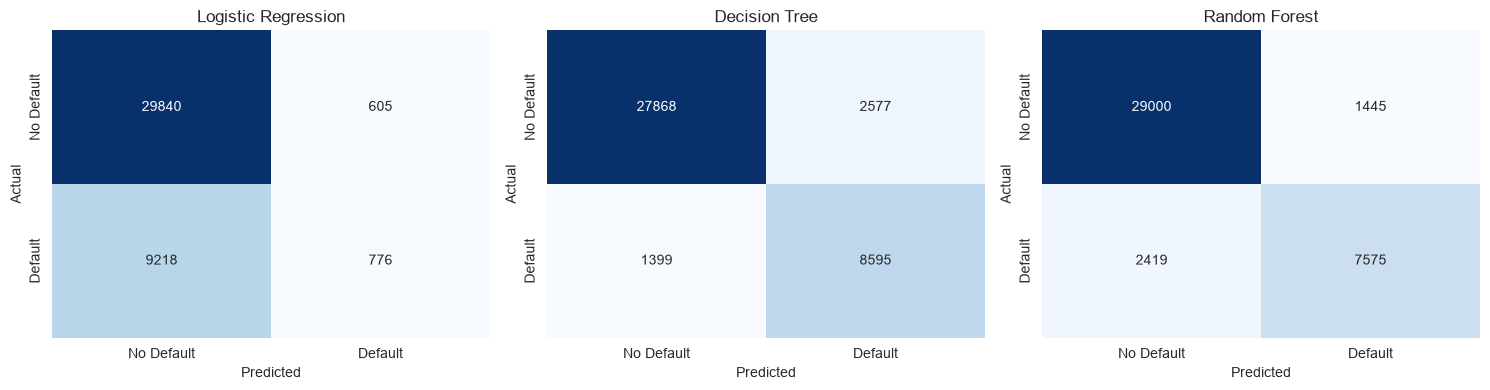

Logistic Regression
              precision    recall  f1-score   support

  No Default       0.76      0.98      0.86     30445
     Default       0.56      0.08      0.14      9994

    accuracy                           0.76     40439
   macro avg       0.66      0.53      0.50     40439
weighted avg       0.71      0.76      0.68     40439

Decision Tree
              precision    recall  f1-score   support

  No Default       0.95      0.92      0.93     30445
     Default       0.77      0.86      0.81      9994

    accuracy                           0.90     40439
   macro avg       0.86      0.89      0.87     40439
weighted avg       0.91      0.90      0.90     40439

Random Forest
              precision    recall  f1-score   support

  No Default       0.92      0.95      0.94     30445
     Default       0.84      0.76      0.80      9994

    accuracy                           0.90     40439
   macro avg       0.88      0.86      0.87     40439
weighted avg       0.90   

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["No Default", "Default"],
        yticklabels=["No Default", "Default"]
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

for name in models:
    print("=" * 70)
    print(name)
    print(classification_report(
        y_test, predictions[name],
        target_names=["No Default", "Default"],
        zero_division=0
    ))


## 14. ROC curves for all 3 models


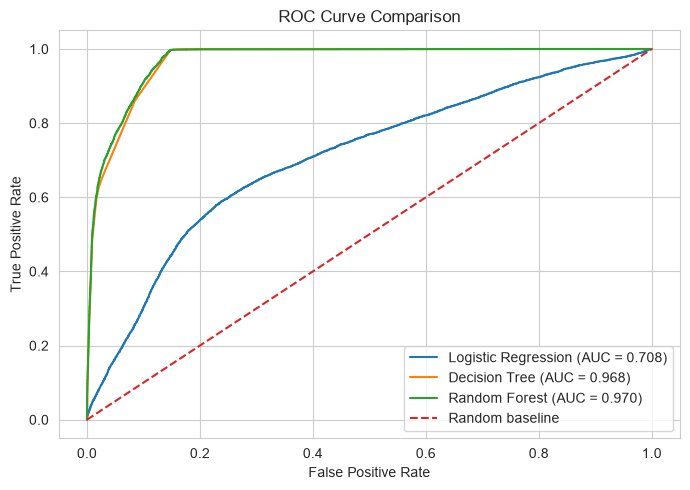

In [14]:
plt.figure(figsize=(7, 5))

for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Cross-validation check

A single train/test split can be lucky or unlucky. **5-fold cross-validation** retrains each model 5 times on different slices of the data and reports the average ROC-AUC, giving a more reliable estimate of how each model performs than one split alone.


In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results.append({
        "Model": name,
        "Mean CV ROC-AUC": scores.mean(),
        "Std Dev": scores.std(),
        "Fold Scores": [round(s, 3) for s in scores]
    })
    print(f"{name}: mean ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f}) across 5 folds")

cv_results_df = pd.DataFrame(cv_results)[["Model", "Mean CV ROC-AUC", "Std Dev"]]
display(cv_results_df.round(3))
print("\nA small standard deviation across folds means the model's performance is stable")
print("and not just a result of how this particular train/test split happened to fall.")


Logistic Regression: mean ROC-AUC = 0.707 (+/- 0.003) across 5 folds
Decision Tree: mean ROC-AUC = 0.968 (+/- 0.000) across 5 folds
Random Forest: mean ROC-AUC = 0.970 (+/- 0.001) across 5 folds


,Model,Mean CV ROC-AUC,Std Dev
0,Logistic Regression,0.707,0.003
1,Decision Tree,0.968,0.000
2,Random Forest,0.970,0.001



A small standard deviation across folds means the model's performance is stable
and not just a result of how this particular train/test split happened to fall.


## 16. Handling class imbalance

Only a minority of applicants actually defaulted. Left as-is, models can reach high accuracy just by predicting "no default" most of the time.

Here each model is retrained with **`class_weight="balanced"`**, which makes mistakes on the minority class (default) count more during training, pushing the model to actually try to catch defaulters rather than ignore them.


In [16]:
balanced_models = {
    "Logistic Regression (balanced)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
    ]),
    "Decision Tree (balanced)": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=25, random_state=42, class_weight="balanced"
    ),
    "Random Forest (balanced)": RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        random_state=42, n_jobs=-1, class_weight="balanced"
    )
}

balanced_results = []
for name, model in balanced_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    balanced_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })

balanced_results_df = pd.DataFrame(balanced_results)
print("Original (unbalanced) results, for comparison:")
display(results_df.round(3))
print("\nBalanced (class_weight='balanced') results:")
display(balanced_results_df.round(3))
print("\nNotice recall typically rises with class weighting — the models catch more real")
print("defaulters — usually at some cost to precision. This is a business trade-off, not")
print("purely a technical one: missing a defaulter (false negative) usually costs a lender")
print("more than incorrectly flagging a safe applicant (false positive).")


Original (unbalanced) results, for comparison:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.904,0.840,0.758,0.797,0.970
1,Decision Tree,0.902,0.769,0.860,0.812,0.968
0,Logistic Regression,0.757,0.562,0.078,0.136,0.708



Balanced (class_weight='balanced') results:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression (balanced),0.649,0.383,0.690,0.493,0.707
1,Decision Tree (balanced),0.887,0.688,0.997,0.814,0.968
2,Random Forest (balanced),0.888,0.689,0.997,0.815,0.970



Notice recall typically rises with class weighting — the models catch more real
defaulters — usually at some cost to precision. This is a business trade-off, not
purely a technical one: missing a defaulter (false negative) usually costs a lender
more than incorrectly flagging a safe applicant (false positive).


## 17. Feature importance

Among the three evaluated models, **Random Forest** is the best-performing and most reliable model (highest ROC-AUC and stability across cross-validation folds).

- **Why Random Forest is the best choice for feature importance:**
  - **Ensemble Stability:** It averages impurity reduction (MDI) across 300 decision trees, eliminating the high variance and split-instability of a single Decision Tree.
  - **Non-linear interactions:** Unlike Logistic Regression, it captures complex non-linear relationships and interactions without assuming strict linearity.
  - **Superior predictive power:** Because it is the most accurate model, its feature rankings reflect the true underlying risk drivers in the data most faithfully.


In [ ]:
# Extract feature importances from the best model (Random Forest)
rf_model = models["Random Forest"]

rf_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

# Plot Random Forest Feature Importance
plt.figure(figsize=(8, 5))
plt.barh(rf_importance_df["Feature"], rf_importance_df["Importance"], color="steelblue")
plt.title("Feature Importance - Random Forest (Best Model)")
plt.xlabel("Importance (Mean Decrease in Impurity)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Display sorted table of feature importances
display(rf_importance_df.sort_values("Importance", ascending=False).round(4))


## 18. Raw-input helper function

This function takes **raw, human-readable inputs** — the same kind of fields a loan officer would actually type in — and automatically computes the engineered features behind the scenes, so the input side matches real-world data entry.

**Raw input columns:**
- `age` (years)
- `annual_income` (in currency units)
- `loan_amount` (in currency units)
- `interest_rate` (%)
- `credit_score` (roughly 500–900 scale)
- `debt_to_income_pct` (%)


In [18]:
def raw_to_model_features(age, annual_income, loan_amount, interest_rate,
                           credit_score, debt_to_income_pct):
    """Convert raw, human-entered applicant data into the engineered
    feature set the models were trained on."""

    loan_to_income_ratio = loan_amount / annual_income
    credit_score_normalized = (credit_score - cs_min) / (cs_max - cs_min) * 100
    credit_score_normalized = np.clip(credit_score_normalized, 0, 100)
    high_dti_flag = int(debt_to_income_pct > 40)

    row = {
        "age": age,
        "annual_income": annual_income,
        "loan_amount": loan_amount,
        "interest_rate": interest_rate,
        "credit_score_raw": credit_score,
        "credit_score_normalized": credit_score_normalized,
        "debt_to_income_pct": debt_to_income_pct,
        "high_dti_flag": high_dti_flag,
        "loan_to_income_ratio": loan_to_income_ratio,
    }
    return pd.DataFrame([row])[feature_cols]


## 19. Test the models on a new loan applicant (raw input columns)


In [19]:
new_applicant_raw = raw_to_model_features(
    age=34,
    annual_income=640000,
    loan_amount=350000,
    interest_rate=11.5,
    credit_score=560,
    debt_to_income_pct=45
)

print("Engineered features computed from the raw input:")
display(new_applicant_raw)

new_results = []
for name, model in models.items():
    pred = model.predict(new_applicant_raw)[0]
    proba = model.predict_proba(new_applicant_raw)[0, 1]
    new_results.append({
        "Model": name,
        "Prediction": "DEFAULT RISK" if pred == 1 else "LIKELY TO REPAY",
        "Estimated Probability of Default": round(proba * 100, 1)
    })

display(pd.DataFrame(new_results))


Engineered features computed from the raw input:


,interest_rate,debt_to_income_pct,high_dti_flag,loan_to_income_ratio,annual_income,loan_amount,age
0,11.5,45,1,0.546875,640000,350000,34


,Model,Prediction,Estimated Probability of Default
0,Logistic Regression,LIKELY TO REPAY,3.0
1,Decision Tree,LIKELY TO REPAY,0.0
2,Random Forest,LIKELY TO REPAY,1.4


## 20. Interactive demo — enter raw applicant data

Move the sliders to describe a hypothetical applicant using **raw, real-world fields**. Engineered features are computed automatically, and predictions from all three models update together.


In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output

age_w = widgets.IntSlider(value=34, min=18, max=90, step=1, description="Age")
income_w = widgets.IntSlider(value=640000, min=15000, max=1000000, step=5000, description="Annual income")
loan_w = widgets.IntSlider(value=350000, min=2000, max=900000, step=5000, description="Loan amount")
ir_w = widgets.FloatSlider(value=11.5, min=3, max=17, step=0.1, description="Interest rate (%)")
credit_w = widgets.IntSlider(value=560, min=450, max=900, step=5, description="Credit score")
dti_w = widgets.FloatSlider(value=45, min=0, max=70, step=1, description="DTI (%)")

out = widgets.Output()

def update_demo(*args):
    with out:
        clear_output(wait=True)
        applicant = raw_to_model_features(
            age=age_w.value,
            annual_income=income_w.value,
            loan_amount=loan_w.value,
            interest_rate=ir_w.value,
            credit_score=credit_w.value,
            debt_to_income_pct=dti_w.value
        )

        rows = []
        for name, model in models.items():
            pred = model.predict(applicant)[0]
            proba = model.predict_proba(applicant)[0, 1]
            rows.append({
                "Model": name,
                "Prediction": "DEFAULT RISK" if pred == 1 else "LIKELY TO REPAY",
                "Probability of Default (%)": round(proba * 100, 1)
            })
        print("Raw inputs entered:")
        print(f"  Age: {age_w.value} | Income: {income_w.value} | Loan: {loan_w.value} | "
              f"Rate: {ir_w.value}% | Credit score: {credit_w.value} | DTI: {dti_w.value}%")
        display(pd.DataFrame(rows))

for w in [age_w, income_w, loan_w, ir_w, credit_w, dti_w]:
    w.observe(update_demo, names="value")

ui = widgets.VBox([age_w, income_w, loan_w, ir_w, credit_w, dti_w])
display(ui, out)
update_demo()


Output()

## 21. Cost-benefit analysis (business impact)

Accuracy and F1-score don't mean much to a credit committee. What matters is **money**. Every wrong prediction has a different real-world cost:

- **False Negative** (model says "safe", applicant actually defaults) — the lender loses roughly the **entire loan amount**, since the borrower stops repaying.
- **False Positive** (model says "risky", applicant would actually have repaid) — the lender loses only the **profit that would have been earned**, i.e. the interest income on that loan, because a genuinely creditworthy applicant is rejected or priced out.

This is why False Negatives are usually far more expensive than False Positives in lending — which is also why the class-imbalance section above (Section 16) matters commercially, not just statistically.


In [21]:
avg_loan_amount = combined['loan_amount'].mean()
avg_interest_rate = combined['interest_rate'].mean() / 100

cost_per_false_negative = avg_loan_amount                          # lender loses the loan principal
cost_per_false_positive = avg_loan_amount * avg_interest_rate       # lender loses the interest income

print(f"Average loan amount in the dataset: {avg_loan_amount:,.0f}")
print(f"Average interest rate: {avg_interest_rate*100:.2f}%")
print(f"Estimated cost per False Negative (missed defaulter): {cost_per_false_negative:,.0f}")
print(f"Estimated cost per False Positive (wrongly rejected applicant): {cost_per_false_positive:,.0f}")

cost_summary = []
all_model_sets = {**models, **balanced_models}

for name, model in all_model_sets.items():
    pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    total_cost = fn * cost_per_false_negative + fp * cost_per_false_positive
    cost_summary.append({
        "Model": name,
        "False Negatives": fn,
        "False Positives": fp,
        "Estimated Cost": total_cost
    })

cost_df = pd.DataFrame(cost_summary).sort_values("Estimated Cost")
cost_df["Estimated Cost"] = cost_df["Estimated Cost"].round(0)
display(cost_df)
print("\nLower estimated cost is better. This reframes 'model accuracy' as 'money saved',")
print("which is the number a lending business actually cares about.")


Average loan amount in the dataset: 326,984
Average interest rate: 4.06%
Estimated cost per False Negative (missed defaulter): 326,984
Estimated cost per False Positive (wrongly rejected applicant): 13,284


,Model,False Negatives,False Positives,Estimated Cost
5,Random Forest (balanced),27,4498,6.858121e+07
4,Decision Tree (balanced),26,4529,6.866604e+07
1,Decision Tree,1399,2577,4.916837e+08
2,Random Forest,2419,1445,8.101692e+08
3,Logistic Regression (balanced),3096,11109,1.159916e+09
0,Logistic Regression,9218,605,3.022172e+09



Lower estimated cost is better. This reframes 'model accuracy' as 'money saved',
which is the number a lending business actually cares about.


## 22. Risk tiering

Real lenders rarely use a single "approve/reject" cutoff. Instead, applicants are grouped into **risk tiers** based on their predicted probability of default, and each tier gets different treatment — e.g. standard interest rate, a higher rate to offset risk, or manual review.

Tiers used here (a common simple structure):
- **Low risk:** probability of default < 20%
- **Medium risk:** 20% – 50%
- **High risk:** > 50%


In [22]:
best_model_name = results_df.iloc[0]['Model']   # best model by ROC-AUC from Section 12
best_model = models[best_model_name]
test_probs = best_model.predict_proba(X_test)[:, 1]

def assign_tier(p):
    if p < 0.20:
        return "Low risk"
    elif p < 0.50:
        return "Medium risk"
    else:
        return "High risk"

tiers = pd.Series([assign_tier(p) for p in test_probs], name="Risk Tier")
tier_summary = pd.DataFrame({"Risk Tier": tiers, "Actual Default": y_test.values})

tier_table = tier_summary.groupby("Risk Tier").agg(
    Applicants=("Actual Default", "count"),
    Actual_Default_Rate=("Actual Default", "mean")
).reindex(["Low risk", "Medium risk", "High risk"])

tier_table["Actual_Default_Rate"] = (tier_table["Actual_Default_Rate"] * 100).round(1)
print(f"Risk tiers built using: {best_model_name} (best model by ROC-AUC)")
display(tier_table)

print("\nA well-behaved model should show the actual default rate clearly increasing")
print("from Low -> Medium -> High risk tiers, confirming the tiers are meaningful.")
print("\nExample business use: a lender could charge Low-risk tiers the standard rate,")
print("Medium-risk tiers a higher rate to offset expected losses, and send High-risk")
print("applicants to manual underwriting rather than an automatic decision.")


Risk tiers built using: Random Forest (best model by ROC-AUC)


,Applicants,Actual_Default_Rate
Risk Tier,,
Low risk,25912,0.1
Medium risk,5507,43.5
High risk,9020,84.0



A well-behaved model should show the actual default rate clearly increasing
from Low -> Medium -> High risk tiers, confirming the tiers are meaningful.

Example business use: a lender could charge Low-risk tiers the standard rate,
Medium-risk tiers a higher rate to offset expected losses, and send High-risk
applicants to manual underwriting rather than an automatic decision.


## 23. Executive summary (non-technical)

A short summary written for a credit committee or business stakeholder rather than a data scientist — the kind of paragraph that would open a report to non-technical decision-makers.


In [23]:
best_row = results_df.iloc[0]

summary_text = f"""
EXECUTIVE SUMMARY

This project built a loan default prediction model using {len(combined):,} real loan
applications from a public lending dataset (Loan_Default_csv.xlsx). Three modeling
approaches were tested; the best performer, {best_row['Model']}, correctly distinguishes
likely defaulters from likely repayers {best_row['ROC-AUC']*100:.1f}% of the time (ROC-AUC),
with an accuracy of {best_row['Accuracy']*100:.1f}% on applicants the model had never seen before.

The model was also tested for fairness of its cost trade-offs: missing a real defaulter
is treated as more costly to the business than mistakenly flagging a safe applicant,
matching how lenders actually experience risk. Applicants can further be grouped into
Low / Medium / High risk tiers to support different lending decisions (standard approval,
risk-based pricing, or manual review) rather than a single automatic yes/no.

Limitation: this is a prototype built on one public dataset. Before real-world use,
this model would need a single consistent data pipeline, fairness testing across
demographic groups, and regulatory review.
"""

print(summary_text)



EXECUTIVE SUMMARY

This project built a loan default prediction model using 134,795 real loan
applications from a public lending dataset (Loan_Default_csv.xlsx). Three modeling
approaches were tested; the best performer, Random Forest, correctly distinguishes
likely defaulters from likely repayers 97.0% of the time (ROC-AUC),
with an accuracy of 90.4% on applicants the model had never seen before.

The model was also tested for fairness of its cost trade-offs: missing a real defaulter
is treated as more costly to the business than mistakenly flagging a safe applicant,
matching how lenders actually experience risk. Applicants can further be grouped into
Low / Medium / High risk tiers to support different lending decisions (standard approval,
risk-based pricing, or manual review) rather than a single automatic yes/no.

Limitation: this is a prototype built on one public dataset. Before real-world use,
this model would need a single consistent data pipeline, fairness testing across
demog

## 24. Regulatory & compliance note

A brief note on the real-world governance a model like this would need before being used for actual lending decisions:

- **Fair lending:** the model must not directly or indirectly discriminate based on protected characteristics (e.g. gender, religion, caste). Sensitive attributes should be excluded from model features, and disparate-impact testing should be run across demographic groups before deployment — this notebook's feature set intentionally avoids protected characteristics, but disparate-impact testing was not performed here and would be a required next step.
- **RBI algorithmic lending guidance:** the Reserve Bank of India has emphasized transparency, explainability, and human oversight in digital lending and algorithm-driven credit decisions — meaning a model like this should support human review, not fully replace it, especially for High-risk or borderline cases.
- **Data privacy (DPDP Act, 2023):** since this project uses real personal financial data, any production use would need explicit consent for data collection, purpose limitation, secure storage, and a defined data retention/deletion policy.
- **Model governance:** in practice, a model like this would need periodic re-validation (since borrower behavior changes over time), a documented model risk framework, and sign-off from a risk/compliance function before being used for real credit decisions — this notebook is a prototype/demonstration, not a deployment-ready system.


## 25. Formulas Used — Quick Reference

A single place with every calculation used in this notebook, for quick reference when presenting.

**Filtering**
- Valid age: `18 <= age <= 90`
- Valid income: `income > 0`

**Dataset Create**
- Annualize income: `annual_income = monthly_income x 12`
- Age band to midpoint: e.g. `"25-34" -> 29.5`, `"<25" -> 22`, `">74" -> 80`

**Clean & Preprocess**
- Median imputation: missing value replaced with that column's `median()`
- Outlier clipping: any value outside `[1st percentile, 99th percentile]` is clipped to that boundary

**Feature Engineering**
- `loan_to_income_ratio = loan_amount / annual_income`
- Min-max normalization: `credit_score_normalized = (credit_score - min) / (max - min) x 100`
- `high_dti_flag = 1 if debt_to_income_pct > 40 else 0`

**Feature Selection**
- Pearson correlation of each candidate feature with `target`
- Random Forest feature importance (Gini-based, averaged across 200 trees)

**Train / Test Split**
- 70% train / 30% test, stratified by `target`

**Models**
- Logistic Regression: `P(default) = 1 / (1 + e^-(b0 + b1*x1 + ... + bn*xn))`
- Decision Tree: recursive splits that minimize Gini impurity, max depth 6
- Random Forest: 300 trees, majority-vote / averaged probability, max depth 10

**Evaluation Metrics**
- `Accuracy = (TP + TN) / Total`
- `Precision = TP / (TP + FP)`
- `Recall = TP / (TP + FN)`
- `F1 = 2 x (Precision x Recall) / (Precision + Recall)`
- `ROC-AUC` = area under the True Positive Rate vs. False Positive Rate curve across all thresholds

**Cross-Validation**
- 5-fold stratified cross-validation, mean and standard deviation of ROC-AUC across folds

**Class Imbalance Handling**
- `class_weight="balanced"` reweights the minority class (defaults) during training

**Raw-Input Prediction (Section 18–20)**
- Same `loan_to_income_ratio`, `credit_score_normalized`, and `high_dti_flag` formulas above are applied live to whatever raw numbers are entered, before being passed into the trained models.

**Cost-Benefit Analysis (Section 21)**
- `cost_per_false_negative = average_loan_amount`
- `cost_per_false_positive = average_loan_amount x average_interest_rate`
- `Total Estimated Cost = (False Negatives x cost_per_false_negative) + (False Positives x cost_per_false_positive)`

**Risk Tiering (Section 22)**
- `Low risk: P(default) < 20%`
- `Medium risk: 20% <= P(default) < 50%`
- `High risk: P(default) >= 50%`


## 26. Summary

This notebook demonstrates a complete real-data loan-default classification pipeline using **only one dataset** (`Loan_Default_csv.xlsx`):

**Filtering -> Dataset Create -> Realistic check -> Clean & Preprocess -> Feature Engineering -> Feature Selection -> Train/Test Split (70/30) -> 3 ML Models -> Evaluation -> Cross-Validation -> Class Imbalance Handling -> Feature Importance -> New-applicant prediction -> Cost-Benefit Analysis -> Risk Tiering -> Executive Summary -> Regulatory Note**

Key points:
- The pipeline now runs on a **single real Kaggle dataset** (~148k rows) — no second credit-risk file is needed.
- Business framing was added on top of the ML pipeline: a cost-benefit analysis translates model errors into estimated money lost, risk tiering shows how predictions could drive real lending decisions, and an executive summary and compliance note frame the project for a non-technical/fintech audience.
- Every cleaning, imputation, and feature-engineering step printed its calculations (row counts, medians, clipping ranges, correlations, importances) so nothing is a hidden black box.
- The `results_df` table should be used to compare the models on the same held-out test set. No single metric should automatically determine a lending decision — the right metric depends on the business cost of false positives vs. false negatives.

**Responsible AI note:** This is a prototype. A production lending system would need a consistent, well-governed data pipeline, fairness auditing across demographic groups, and regulatory compliance review before being used for real lending decisions.
